# Pausa práctica 1 — ¿Por qué el HPC clásico ya no alcanza?

**Contexto:** acabamos de ver que 500 activos en un portafolio, o una flota de 50 camiones con 200 paradas, generan un espacio de soluciones que crece **exponencialmente** (2ⁿ), no linealmente.

En este notebook lo vemos con números reales: ¿cuánto tarda una computadora clásica en enumerar *todas* las combinaciones posibles a medida que crece el problema?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Supongamos una computadora clásica rápida: 10^9 combinaciones evaluadas por segundo
COMBINACIONES_POR_SEGUNDO = 1e9

n_values = np.arange(1, 91)
combinaciones = 2.0 ** n_values
tiempo_segundos = combinaciones / COMBINACIONES_POR_SEGUNDO
tiempo_anios = tiempo_segundos / (60 * 60 * 24 * 365)

for n in [10, 30, 50, 70, 80, 90]:
    idx = n - 1
    if tiempo_anios[idx] < 1:
        print(f"n = {n:3d} variables  ->  {tiempo_segundos[idx]:.4f} segundos")
    else:
        print(f"n = {n:3d} variables  ->  {tiempo_anios[idx]:.3e} años")


n =  10 variables  ->  0.0000 segundos
n =  30 variables  ->  1.0737 segundos
n =  50 variables  ->  1125899.9068 segundos
n =  70 variables  ->  3.744e+04 años
n =  80 variables  ->  3.833e+07 años
n =  90 variables  ->  3.925e+10 años


**Nota:** la edad del universo es de aproximadamente 1.38 × 10¹⁰ años. Verás en el output de arriba en qué valor de `n` la enumeración por fuerza bruta ya supera esa cifra.

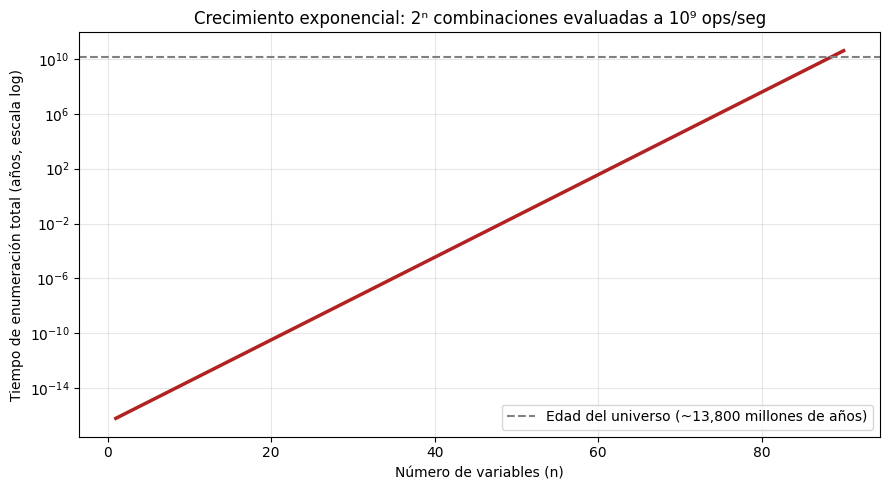

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_values, tiempo_anios, color="#B22222", linewidth=2.5)
ax.set_yscale("log")
ax.axhline(1.38e10, color="gray", linestyle="--", linewidth=1.5, label="Edad del universo (~13,800 millones de años)")
ax.set_xlabel("Número de variables (n)")
ax.set_ylabel("Tiempo de enumeración total (años, escala log)")
ax.set_title("Crecimiento exponencial: 2ⁿ combinaciones evaluadas a 10⁹ ops/seg")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("crecimiento_exponencial.png", dpi=140)
plt.show()
